<div align="center">

![Course](https://img.shields.io/badge/Course-Advanced%20Data%20Science%20Lab-blue?style=for-the-badge&logo=python&logoColor=white)
![Code](https://img.shields.io/badge/Code-MCA33PE21-informational?style=for-the-badge)
![Assignment](https://img.shields.io/badge/Assignment-01-success?style=for-the-badge)

---

# Advanced Data Science Lab [MCA33PE21]
## FA 1 Activity
### Streamlit EDA + ML App

---
<br>

| Field | Details |
|---|---|
| **Academic Year** | **2026-2027** |
| **Class / Division** | **SYMCA (Semester-I)** |
| **PRN** | 125M1H002|
| **Student Name** | Shreyash Patil |
| **Submission Date** | 02-08-2026 |
</div>

# 1.Importing Libraries

In [1]:
import pickle
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from collections import Counter
from scipy import stats
from scipy.stats import pearsonr

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    mean_squared_error,
    r2_score
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.style.use(
    'seaborn-v0_8-whitegrid'
    if 'seaborn-v0_8-whitegrid' in plt.style.available
    else 'default'
)


print("Libraries loaded")

Libraries loaded


#

# 2.Loading the data

In [2]:
# Loading Dataset
df = pd.read_csv('data/aqi_data.csv')

# Rename columns to standard/consistent naming
df.rename(columns={
    'city':         'City',
    'date':         'Date',
    'pm25':         'PM2_5',
    'pm10':         'PM10',
    'no2':          'NO2',
    'so2':          'SO2',
    'co':           'CO',
    'o3':           'O3',
    'aqi':          'AQI',
    'aqi_category': 'AQI_Category'
}, inplace=True)

# Parse date (format is YYYY-MM-DD)
df['Date'] = pd.to_datetime(df['Date'])
df['City'] = df['City'].str.strip()
df = df.sort_values(['Date', 'City']).reset_index(drop=True)
df['Year']= df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%b')

print(f"Shape: {df.shape}")
df.head()

Shape: (32870, 13)


,City,Date,PM2_5,PM10,NO2,SO2,CO,O3,AQI,AQI_Category,Year,Month,Month_Name
0,Ahmedabad,2015-01-01,5.000000,67.017870,44.943206,20.177149,0.290421,37.919202,30,Good,2015,1,Jan
1,Bengaluru,2015-01-01,65.168592,145.090645,20.196469,7.609377,0.871098,47.708038,82,Satisfactory,2015,1,Jan
2,Chennai,2015-01-01,224.223627,314.623460,43.732344,8.120949,0.670627,52.107131,216,Poor,2015,1,Jan
3,Delhi,2015-01-01,99.868566,147.103280,49.715328,19.615149,0.729754,46.487946,103,Moderate,2015,1,Jan
4,Hyderabad,2015-01-01,80.562953,174.158005,41.135471,11.745565,0.599973,67.004496,103,Moderate,2015,1,Jan


#

# 3.Data Representation & Measures of Central Tendency

## Dataset Info & Missing Values



In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32870 entries, 0 to 32869
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   City          32870 non-null  object        
 1   Date          32870 non-null  datetime64[ns]
 2   PM2_5         32870 non-null  float64       
 3   PM10          32870 non-null  float64       
 4   NO2           32870 non-null  float64       
 5   SO2           32870 non-null  float64       
 6   CO            32870 non-null  float64       
 7   O3            32870 non-null  float64       
 8   AQI           32870 non-null  int64         
 9   AQI_Category  32870 non-null  object        
 10  Year          32870 non-null  int32         
 11  Month         32870 non-null  int32         
 12  Month_Name    32870 non-null  object        
dtypes: datetime64[ns](1), float64(6), int32(2), int64(1), object(3)
memory usage: 3.0+ MB


## Processing Data

In [6]:
# Check missing values -
print("Total missing values across dataset:", df.isnull().sum())


Total missing values across dataset: City            0
Date            0
PM2_5           0
PM10            0
NO2             0
SO2             0
CO              0
O3              0
AQI             0
AQI_Category    0
Year            0
Month           0
Month_Name      0
dtype: int64


## Descriptive Statistics



In [8]:
# Summary statistics and correlation with AQI for all pollutants
pollutants = ['PM2_5', 'PM10', 'NO2', 'SO2', 'CO', 'O3']

pollutant_analysis = pd.DataFrame({
    'Mean Concentration': df[pollutants].mean(),
    'Median Concentration': df[pollutants].median(),
    'Std Dev': df[pollutants].std(),
    'Min': df[pollutants].min(),
    'Max': df[pollutants].max(),
    'Correlation with AQI': df[pollutants].apply(lambda x: df['AQI'].corr(x))
}).round(2)

pollutant_analysis.index.name = 'Pollutant'
pollutant_analysis  


,Mean Concentration,Median Concentration,Std Dev,Min,Max,Correlation with AQI
Pollutant,,,,,,
PM2_5,80.76,80.34,39.06,5.0,248.08,0.98
PM10,130.76,130.02,43.94,10.0,330.01,0.96
NO2,40.17,40.14,14.85,5.0,97.45,0.04
SO2,12.00,11.98,4.88,2.0,34.40,0.00
CO,0.80,0.80,0.30,0.1,1.93,0.00
O3,49.98,49.98,14.91,10.0,118.43,0.04


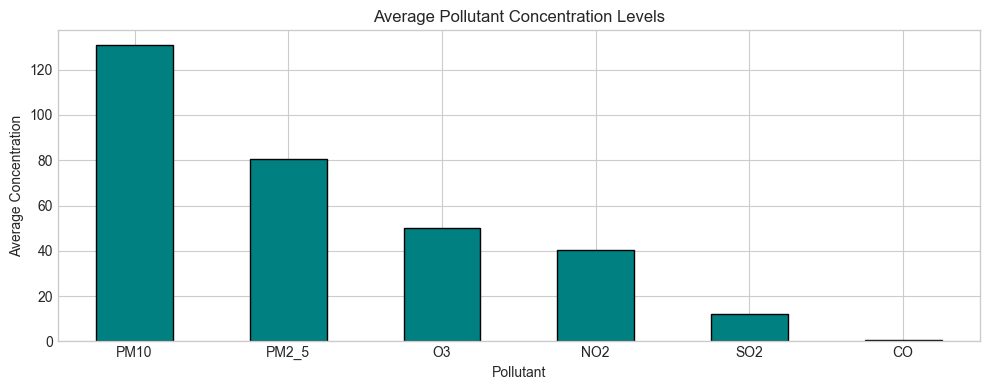

In [9]:
# Plot average pollutant concentration levels
pollutants = ['PM2_5', 'PM10', 'NO2', 'SO2', 'CO', 'O3']
avg_pollutants = df[pollutants].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 4))
avg_pollutants.plot(kind='bar', color='teal', edgecolor='black')
plt.title('Average Pollutant Concentration Levels')
plt.xlabel('Pollutant')
plt.ylabel('Average Concentration')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()  


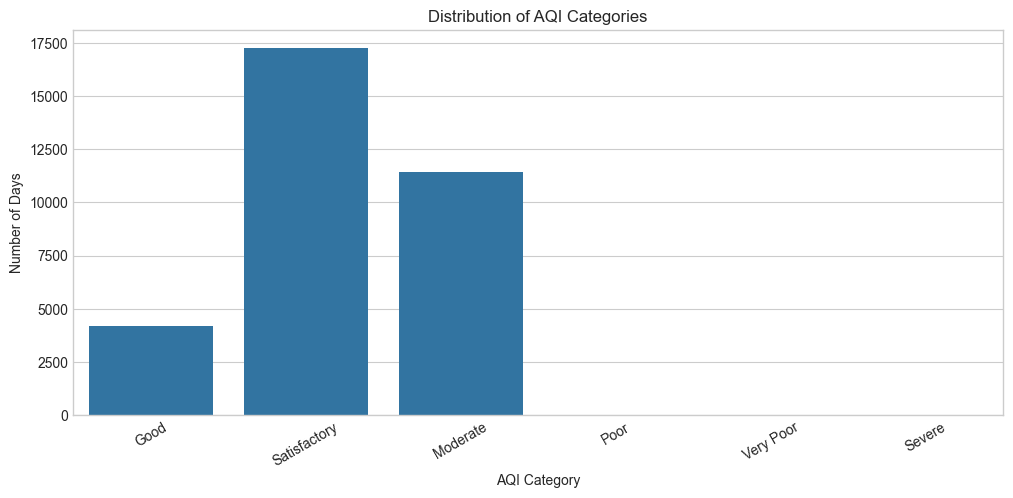

In [10]:
# Plot AQI category distribution in increasing severity order
sns.countplot(
    x=df['AQI_Category'],
    order=['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
)

plt.xlabel('AQI Category')
plt.ylabel('Number of Days')
plt.title('Distribution of AQI Categories')
plt.xticks(rotation=30)
plt.show()

## Central Tendancy for AQI

In [11]:
aqi = df['AQI']
print(f"Mean     : {aqi.mean():.2f}")
print(f"Median   : {aqi.median():.2f}")
print(f"Mode     : {aqi.mode()[0]:.2f}")
print(f"Std Dev  : {aqi.std():.2f}")
print(f"Variance : {aqi.var():.2f}")
print(f"Skewness : {aqi.skew():.4f}")
print(f"Kurtosis : {aqi.kurtosis():.4f}")
print(f"Q1       : {aqi.quantile(0.25):.2f}")
print(f"Q3       : {aqi.quantile(0.75):.2f}")
print(f"IQR      : {aqi.quantile(0.75) - aqi.quantile(0.25):.2f}")


Mean     : 88.12
Median   : 88.00
Mode     : 89.00
Std Dev  : 31.90
Variance : 1017.32
Skewness : 0.1472
Kurtosis : -0.2892
Q1       : 65.00
Q3       : 110.00
IQR      : 45.00


The AQI data exhibits a nearly symmetric distribution with a slight positive skewness (0.1472), where the mean (88.12) is very close to the median (88.00). The standard deviation of 31.90 indicates moderate spread in AQI levels. The negative kurtosis (-0.2892) indicates a platykurtic distribution with slightly lighter tails than a normal distribution. The IQR of 45.00 shows that the middle 50% of AQI values fall between 65.00 (Q1) and 110.00 (Q3).

To confirm this we plot histogram   


## Histogram + KDE

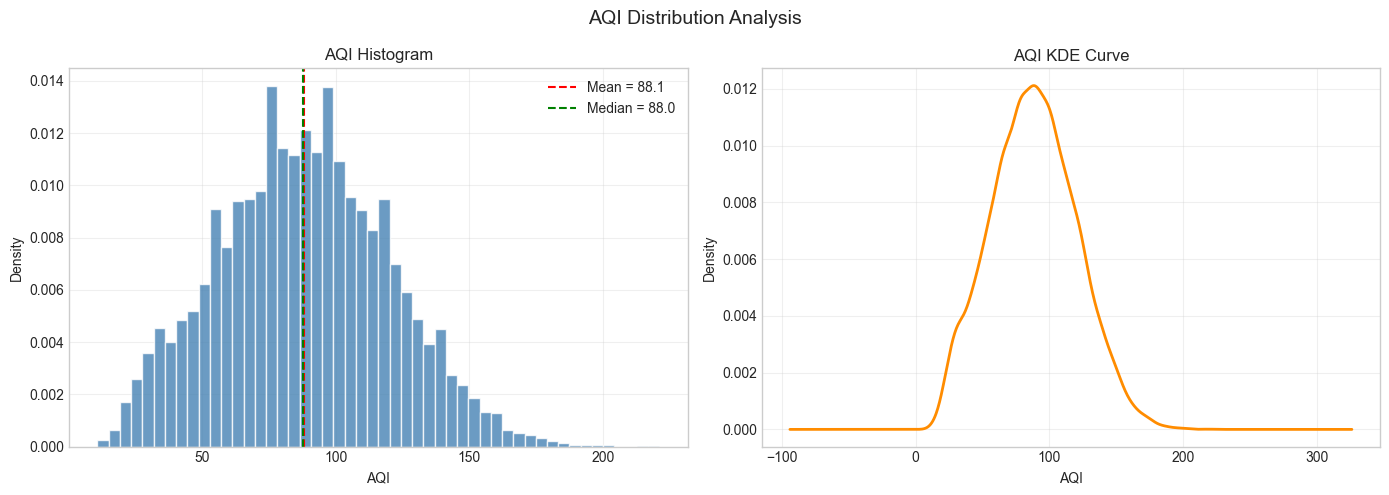

In [12]:
aqi = df['AQI']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(aqi, bins=50, density=True, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(aqi.mean(), color='red', linestyle='--', label=f'Mean = {aqi.mean():.1f}')
axes[0].axvline(aqi.median(), color='green', linestyle='--', label=f'Median = {aqi.median():.1f}')
axes[0].set_title('AQI Histogram')
axes[0].set_xlabel('AQI')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].grid(alpha=0.3)

# KDE Plot
aqi.plot(kind='kde', ax=axes[1], color='darkorange', linewidth=2)
axes[1].set_title('AQI KDE Curve')
axes[1].set_xlabel('AQI')
axes[1].grid(alpha=0.3)

# Overall Title
fig.suptitle('AQI Distribution Analysis', fontsize=14)

plt.tight_layout()
plt.show()

## AQI Bucket Bar + Pie Chart


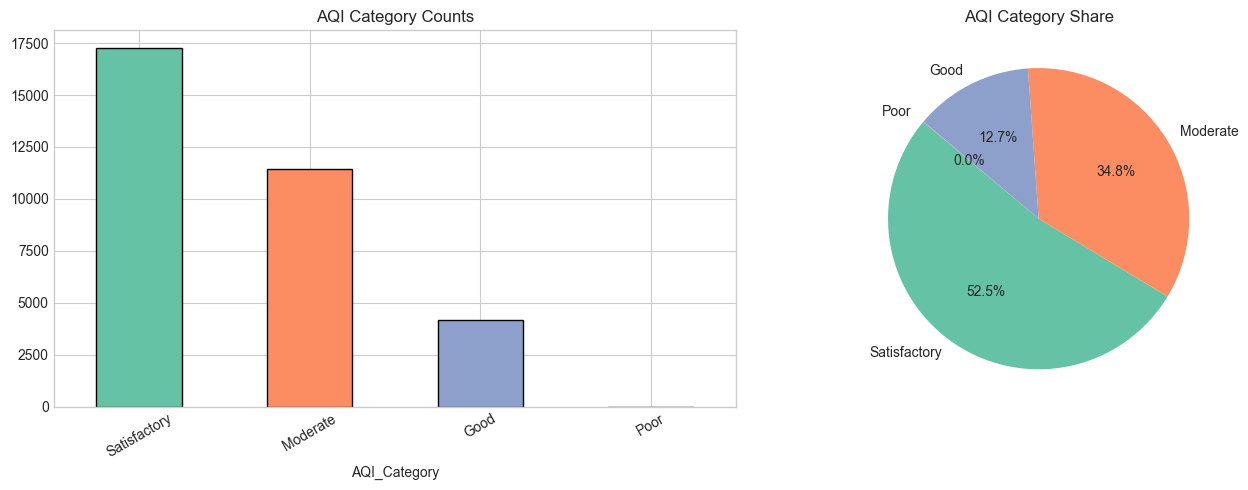

In [13]:
bucket = df['AQI_Category'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bucket.plot(kind='bar', ax=axes[0], color=sns.color_palette('Set2'), edgecolor='black')
axes[0].set_title('AQI Category Counts')
axes[0].tick_params(axis='x', rotation=30)

axes[1].pie(bucket, labels=bucket.index, autopct='%1.1f%%', colors=sns.color_palette('Set2'), startangle=140)
axes[1].set_title('AQI Category Share')

plt.tight_layout()
plt.show()


The charts show that most AQI values fall under Satisfactory (52.5%) and Moderate (34.8%), followed by Good (12.7%) and Poor (0.03%). This indicates that the majority of air quality readings in the dataset are in the acceptable to moderate range.

#


# 4. Correlation, Regression & Time Series

## Heatmap

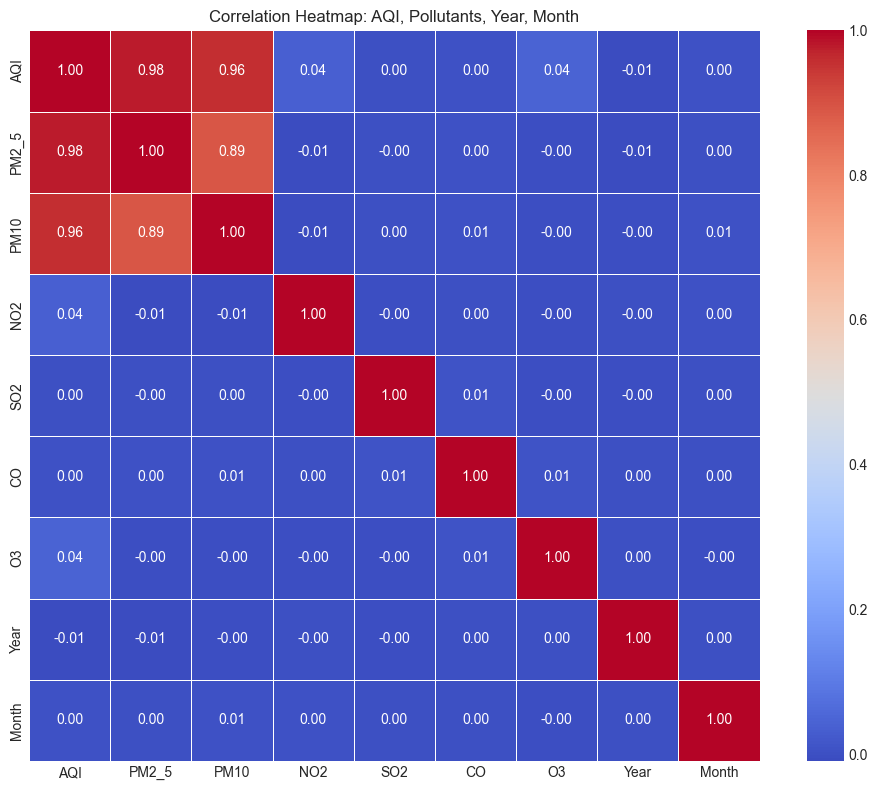

In [14]:
# Visualize correlations among AQI, pollutants, year and month
corr_cols = ['AQI', 'PM2_5', 'PM10', 'NO2', 'SO2', 'CO', 'O3', 'Year', 'Month']
corr = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap: AQI, Pollutants, Year, Month')
plt.tight_layout()
plt.show()

The correlation heatmap reveals that AQI has an exceptionally strong positive linear correlation with PM2.5 (0.98) and PM10 (0.96), identifying particulate matter as the dominant driver of AQI levels. Other gaseous pollutants such as O3 (0.04), NO2 (0.04), CO (0.00), and SO2 (0.00) show negligible linear correlation with AQI in this dataset. Additionally, Year and Month show virtually zero linear association with AQI.


## Time Series: AQI Trend (Delhi)

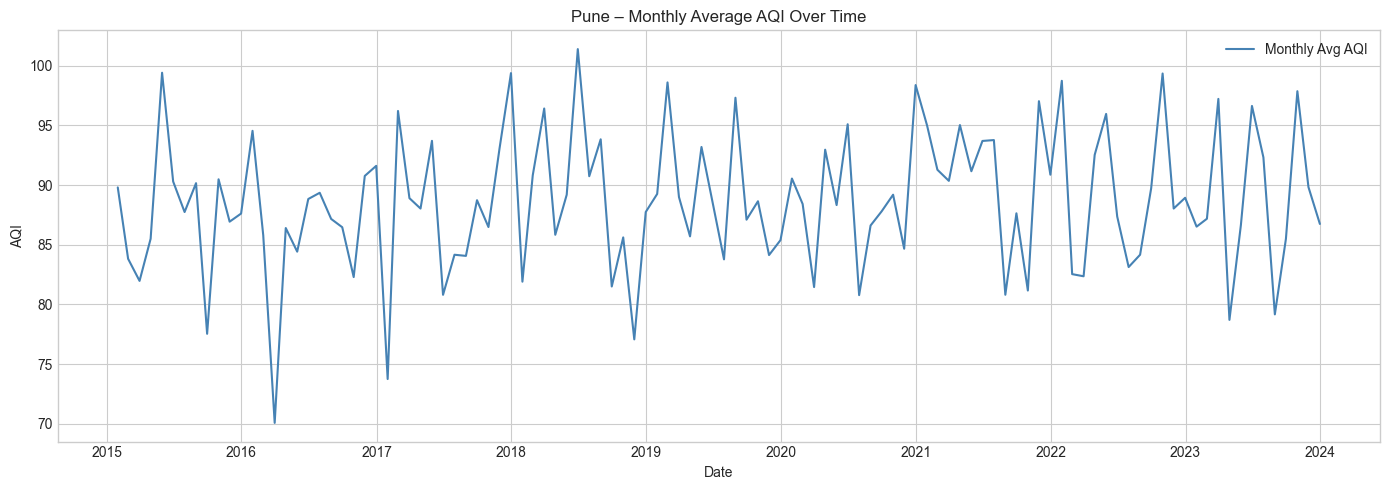

In [15]:
delhi_ts = df[df['City'] == 'Pune'][['Date','AQI']].set_index('Date').sort_index()
delhi_monthly = delhi_ts['AQI'].resample('M').mean()

plt.figure(figsize=(14, 5))
plt.plot(delhi_monthly, color='steelblue', linewidth=1.5, label='Monthly Avg AQI')
plt.title('Pune – Monthly Average AQI Over Time')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.legend()
plt.tight_layout()
plt.show()


## City-wise AQI Trend (Multi-line)

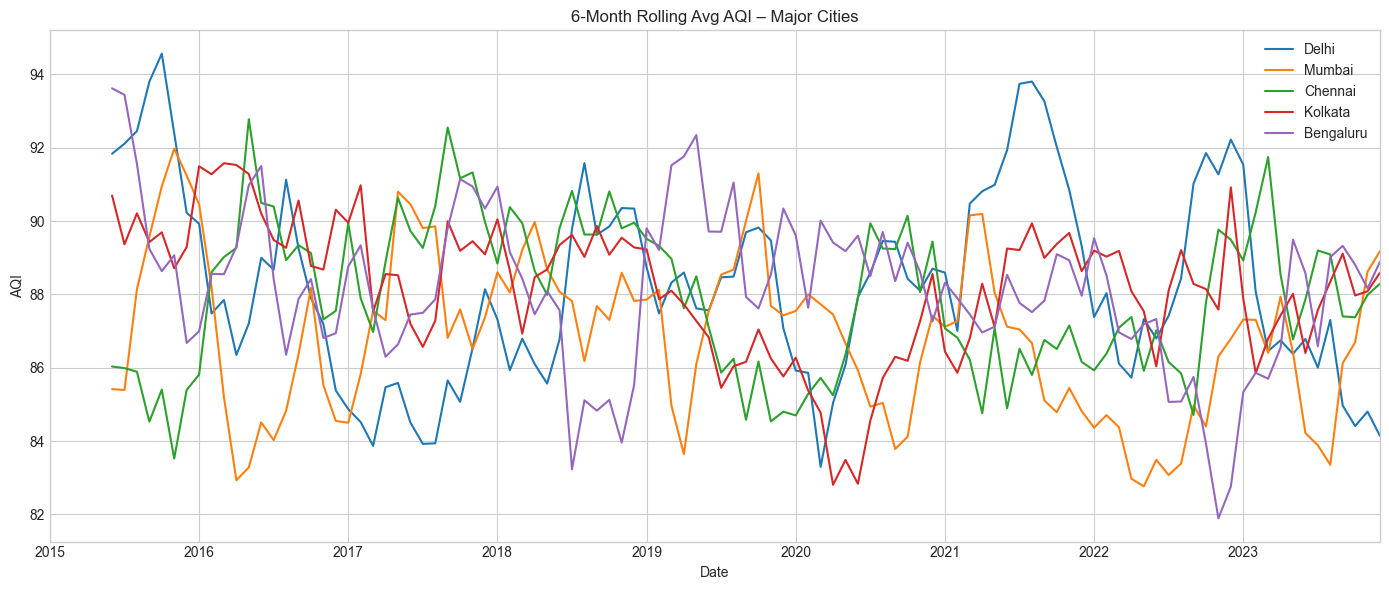

In [16]:
cities_ts = ['Delhi','Mumbai','Chennai','Kolkata','Bengaluru']
plt.figure(figsize=(14, 6))
for city in cities_ts:
    ts = df[df['City'] == city][['Date','AQI']].set_index('Date').sort_index()
    ts['AQI'].resample('ME').mean().rolling(6).mean().plot(label=city)
plt.title('6-Month Rolling Avg AQI – Major Cities')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.legend()
plt.tight_layout()
plt.show()

##  Simple Linear Regression (PM2.5 → AQI)

=== Simple Linear Regression: PM2.5 → AQI ===
Coefficient : 0.8003
Intercept   : 23.4702
R² Score    : 0.9607
RMSE        : 6.3351


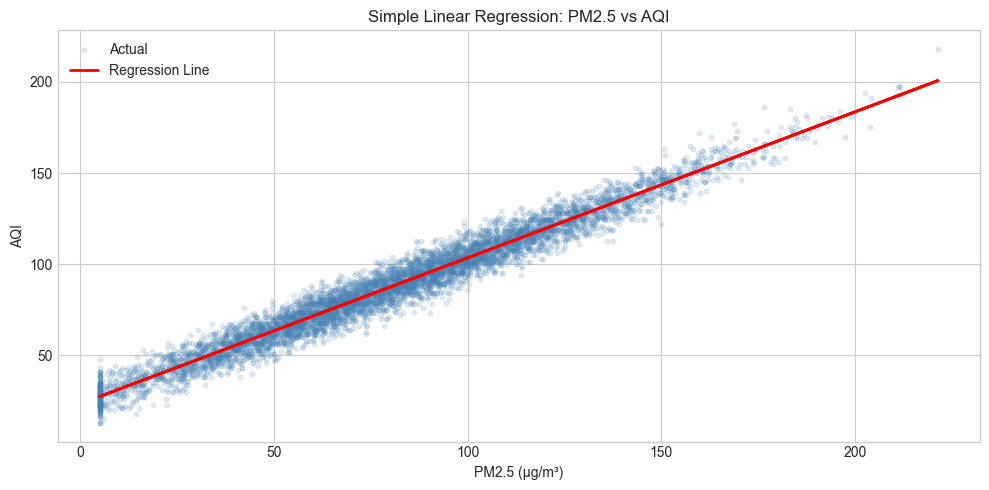

In [17]:
# Simple linear regression: PM2.5 -> AQI
X = df[['PM2_5']].values
y = df['AQI'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

print("=== Simple Linear Regression: PM2.5 → AQI ===")
print(f"Coefficient : {lr.coef_[0]:.4f}")
print(f"Intercept   : {lr.intercept_:.4f}")
print(f"R² Score    : {r2_score(y_test, y_pred):.4f}")
print(f"RMSE        : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

plt.figure(figsize=(10, 5))
plt.scatter(X_test, y_test, alpha=0.15, s=10, label='Actual', color='steelblue')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')
plt.xlabel('PM2.5 (µg/m³)')
plt.ylabel('AQI')
plt.title('Simple Linear Regression: PM2.5 vs AQI')
plt.legend()
plt.tight_layout()
plt.show()  


The simple linear regression model demonstrates a strong positive relationship between PM2.5 concentration and AQI, with a coefficient of 0.8003 and an intercept of 23.4856. The high R² score of 0.9591 indicates that PM2.5 alone accounts for approximately 95.9% of the variance in AQI. The low RMSE of 6.45 further confirms the strong predictive power of PM2.5 for estimating AQI in this dataset.

# 5. Model Training


## Feature Engineering

In [18]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['DayOfYear'] = df['Date'].dt.dayofyear
df['Is_Weekend'] = df['DayOfWeek'].isin([5, 6]).astype(int)

df['sin_month'] = np.sin(2 * np.pi * df['Month'] / 12)
df['cos_month'] = np.cos(2 * np.pi * df['Month'] / 12)
df['sin_dayofyear'] = np.sin(2 * np.pi * df['DayOfYear'] / 365.25)
df['cos_dayofyear'] = np.cos(2 * np.pi * df['DayOfYear'] / 365.25)

df['Season'] = np.select(
    [df['Month'].isin([12, 1, 2]), df['Month'].isin([3, 4, 5]), df['Month'].isin([6, 7, 8, 9])],
    [0, 1, 2],
    default=3
)

numeric_features = [
    'PM2_5', 'PM10', 'NO2', 'SO2', 'CO', 'O3',
    'Year', 'Month', 'Day', 'DayOfWeek', 'DayOfYear', 'Is_Weekend', 'Season',
    'sin_month', 'cos_month', 'sin_dayofyear', 'cos_dayofyear'
]
categorical_features = ['City']
feature_columns = categorical_features + numeric_features
target_column = 'AQI_Category'


## Chronological train-test split
The model trains on 2015-2022 and evaluates on the unseen year 2023.

In [19]:
train_df = df[df['Date'] < '2023-01-01'].copy()
test_df = df[df['Date'] >= '2023-01-01'].copy()

X_train = train_df[feature_columns]
X_test = test_df[feature_columns]
y_train = train_df[target_column]
y_test = test_df[target_column]

print(f'Training samples: {len(X_train):,}')
print(f'Testing samples: {len(X_test):,}')
print(f'Train period: {train_df["Date"].min().date()} to {train_df["Date"].max().date()}')
print(f'Test period: {test_df["Date"].min().date()} to {test_df["Date"].max().date()}')


Training samples: 29,220
Testing samples: 3,650
Train period: 2015-01-01 to 2022-12-31
Test period: 2023-01-01 to 2023-12-31


In [20]:
def make_preprocessor():
    return ColumnTransformer(
        transformers=[
            ('numeric', StandardScaler(), numeric_features),
            ('city', OneHotEncoder(handle_unknown='ignore'), categorical_features)
        ]
    )

models = {
    'Logistic Regression': LogisticRegression(max_iter=3000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(min_samples_leaf=2, random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, class_weight='balanced_subsample', n_jobs=-1, random_state=42
    )
}

trained_models = {}
results = []

for name, classifier in models.items():
    pipeline = Pipeline([
        ('preprocessor', make_preprocessor()),
        ('classifier', classifier)
    ])
    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)

    trained_models[name] = pipeline
    results.append({'Model': name, 'Accuracy (%)': accuracy * 100})

results_df = pd.DataFrame(results).sort_values('Accuracy (%)', ascending=False).reset_index(drop=True)
display(results_df.style.format({'Accuracy (%)': '{:.2f}%'}))
    

,Model,Accuracy (%)
0,Logistic Regression,99.67%
1,Decision Tree,97.45%
2,Random Forest,97.37%


In [21]:
best_model_name = results_df.loc[0, 'Model']
best_model = trained_models[best_model_name]
best_predictions = best_model.predict(X_test)
best_accuracy = accuracy_score(y_test, best_predictions)
labels = sorted(y_train.unique())

print(f'Best model: {best_model_name}')
print(f'Accuracy: {best_accuracy:.2%}')

Best model: Logistic Regression
Accuracy: 99.67%


In [22]:
artifact = {
    'model': best_model,
    'model_name': best_model_name,
    'feature_columns': feature_columns,
    'numeric_features': numeric_features,
    'categorical_features': categorical_features,
    'target_column': target_column
}

with open('models/best_aqi_classifier.pkl', 'wb') as file:
    pickle.dump(artifact, file)

print(f'Saved {best_model_name} to models/best_aqi_classifier.pkl')


Saved Logistic Regression to models/best_aqi_classifier.pkl
